# ResNet50 Transfer Learning

ResNet50 pretrained on ImageNet provides:
- **1000 classes** trained on 1.2M images
- **224×224 input resolution** - perfect match for our dataset
- **Deep architecture** 50 layers
- **Strong feature extractors** from low-level (edges) to high-level (object parts)

**Advantages over CIFAR-10 pretraining:**
- Same resolution (224×224 vs 32×32 upsampling)
- Larger, more diverse pretraining dataset (ImageNet vs CIFAR-10)


In [1]:
# Load pretrained ResNet50
import torch
import torchvision.models as models
import torch.nn as nn
from torchvision.models import ResNet50_Weights

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}\n')

resnet50 = models.resnet50(weights=ResNet50_Weights.DEFAULT)

# Inspect architecture
print('Original ResNet50 architecture:')
print(resnet50)
print(f'\nOriginal FC layer: {resnet50.fc}')
print(f'Number of input features to FC: {resnet50.fc.in_features}')

Device: cuda

Original ResNet50 architecture:
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): C

In [2]:
# Replace final layer to 15 classes to match our dataset

n_classes = 15
resnet50.fc = nn.Linear(resnet50.fc.in_features, n_classes)

print(f'\nModified FC layer: {resnet50.fc}')
print(f'Total trainable parameters: {sum(p.numel() for p in resnet50.parameters() if p.requires_grad):,}')


Modified FC layer: Linear(in_features=2048, out_features=15, bias=True)
Total trainable parameters: 23,538,767


### Design Choices Explanation:

**Why Replace Only FC Layer:**
- ResNet's conv layers learned universal features (edges, textures, shapes) from ImageNet
- Only final FC layer is task-specific (1000 ImageNet classes -> 15 animal classes)

**Freezing Strategy:**
We'll experiment with 3 approaches:
1. **Frozen backbone**: Freeze all conv layers, train only FC (fastest, feature extraction)
2. **Partial unfreezing**: Unfreeze layer4 (the last resnet block) + FC (balance speed/adaptation)
3. **Full fine-tuning**: Train all layers with low LR (slowest, best adaptation)

In [3]:
import sys

# Load github repo
!git clone https://github.com/erezpoliak/AnimalClassifier

# Remove unnecessary LICENSE.md from dataset
!rm /content/AnimalClassifier/animal_data/LICENSE.md

sys.path.append('/content/AnimalClassifier/EX4 - Project')

DATA_PATH = '/content/AnimalClassifier/animal_data'

Cloning into 'AnimalClassifier'...
remote: Enumerating objects: 2053, done.
remote: Counting objects: 100% (91/91), done.
remote: Compressing objects: 100% (69/69), done.
remote: Total 2053 (delta 43), reused 64 (delta 16), pack-reused 1962 (from 2)
Receiving objects: 100% (2053/2053), 45.32 MiB | 51.96 MiB/s, done.
Resolving deltas: 100% (44/44), done.


### We will load our animal dataset with ResNet50 Normalization:
ResNet50 was pretrained with ImageNet mean/std values. Using the same normalization ensures:
- Input distribution matches what the model expects
- Pretrained features activate correctly
- Better transfer learning performance

Using custom normalization (from our dataset) would shift the input distribution, degrading pretrained feature quality.

In [4]:
def count_trainable_params(model):
  return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [5]:
# Load and prepare animal dataset
from torchvision import datasets, transforms
from dataset_util import dataset_split
from torch.utils.data import Subset

# ImageNet normalization stats
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Transfroms with ImageNet normalization, and augmentations we used in cnn_scratch for animal dataset
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])
val_test_transform = transforms.Compose([
      transforms.Resize((224, 224)),
      transforms.ToTensor(),
      transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    ])

base_dataset = datasets.ImageFolder(DATA_PATH, transform=transforms.ToTensor())
train_idx, val_idx, test_idx = dataset_split(base_dataset, 0.7, 0.15)

train_indices = train_idx.indices
val_indices = val_idx.indices
test_indices = test_idx.indices

train_ds = Subset(datasets.ImageFolder(DATA_PATH, transform=train_transform), train_indices)
val_ds = Subset(datasets.ImageFolder(DATA_PATH, transform=val_test_transform), val_indices)
test_ds = Subset(datasets.ImageFolder(DATA_PATH, transform=val_test_transform), test_indices)

print(f'Train size: {len(train_ds)}')
print(f'Val size: {len(val_ds)}')
print(f'Test size: {len(test_ds)}')

Train size: 1360
Val size: 291
Test size: 293


In [6]:
# Training configuration
BATCH_SIZE = 32
EPOCHS = 50
PATIENCE = 10
WEIGHT_DECAY = 0.001

train_loader = torch.utils.data.DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# Experiment 1: Frozen Backbone (Feature Extraction)

**Strategy**: Freeze all conv layers, train only FC layer
- Expected fastest training
- Baseline performance: Tests if ImageNet features transfer directly


In [10]:
from model_util import train, evaluate
import time

print('Experiment 1: Frozen Backbone (Feature Extraction)\n')

model_frozen = models.resnet50(weights=ResNet50_Weights.DEFAULT)
model_frozen.fc = nn.Linear(model_frozen.fc.in_features, n_classes)

# Freeze all layers except FC
for param in model_frozen.parameters():
    param.requires_grad = False
for param in model_frozen.fc.parameters():
    param.requires_grad = True

model_frozen = model_frozen.to(device)

print(f'Trainable parameters: {count_trainable_params(model_frozen):,}\n')

# Higher LR since only training FC
optimizer_frozen = torch.optim.Adam(model_frozen.parameters(), lr=0.0001, weight_decay=WEIGHT_DECAY)
start_time = time.time()
model_frozen, history_frozen = train(model_frozen, train_loader, val_loader, optimizer_frozen, EPOCHS, PATIENCE, device)
print()
train_time_frozen = time.time() - start_time

print(f'\nTraining time: {train_time_frozen/60:.2f} min')

Experiment 1: Frozen Backbone (Feature Extraction)

Trainable parameters: 30,735

Epoch 1/50 - Train Loss: 2.6203 - Train Acc: 0.1904 - Val Loss: 2.4946 - Val Acc: 0.4330
Epoch 5/50 - Train Loss: 1.8041 - Train Acc: 0.9213 - Val Loss: 1.7236 - Val Acc: 0.9450
Epoch 10/50 - Train Loss: 1.1356 - Train Acc: 0.9632 - Val Loss: 1.1150 - Val Acc: 0.9656
Epoch 15/50 - Train Loss: 0.7740 - Train Acc: 0.9757 - Val Loss: 0.7814 - Val Acc: 0.9691
Epoch 20/50 - Train Loss: 0.5546 - Train Acc: 0.9772 - Val Loss: 0.5594 - Val Acc: 0.9794
Epoch 25/50 - Train Loss: 0.4261 - Train Acc: 0.9787 - Val Loss: 0.4496 - Val Acc: 0.9794
Epoch 30/50 - Train Loss: 0.3384 - Train Acc: 0.9846 - Val Loss: 0.3413 - Val Acc: 0.9794
Epoch 35/50 - Train Loss: 0.2741 - Train Acc: 0.9831 - Val Loss: 0.3007 - Val Acc: 0.9794
Epoch 40/50 - Train Loss: 0.2312 - Train Acc: 0.9919 - Val Loss: 0.2582 - Val Acc: 0.9828
Epoch 45/50 - Train Loss: 0.2123 - Train Acc: 0.9875 - Val Loss: 0.2287 - Val Acc: 0.9828
Epoch 50/50 - Train 

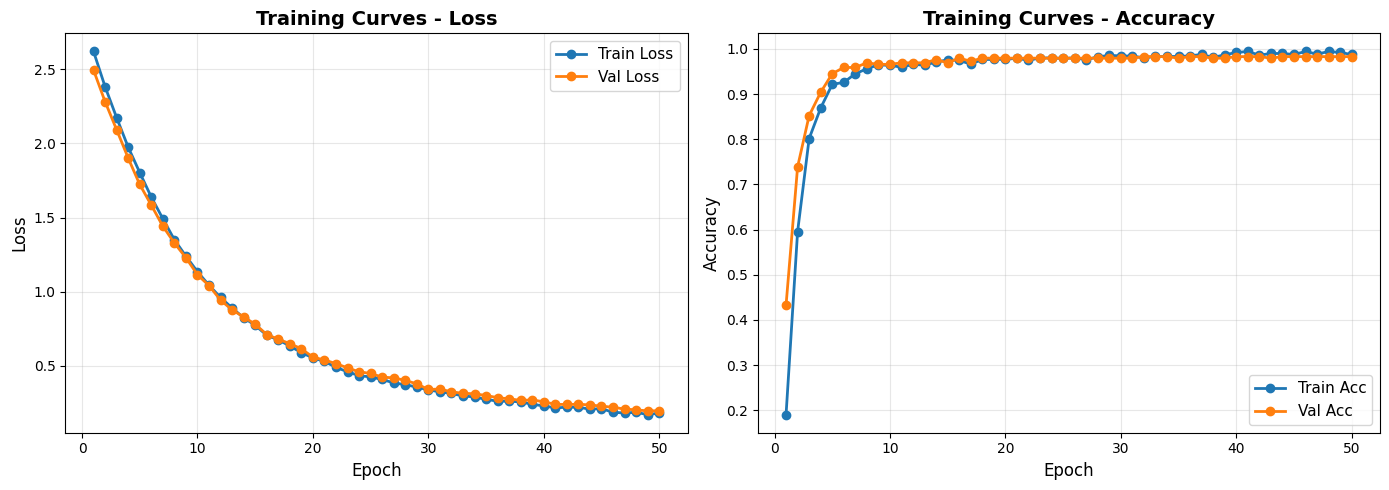

In [11]:
# Plot training curves
from model_util import plot_training_curves

plot_training_curves(history_frozen)

The training curves are smooth, and the validation tracks the training closely, very stable training with no signs of overfitting.

In [12]:
# Test loss and test accuracy

frozen_test_loss, forzen_test_acc = evaluate(model_frozen, test_loader, device)
print(f'Test loss: {frozen_test_loss:.4f}')
print(f'Test accuracy: {forzen_test_acc:.4f}')

Test loss: 0.1947
Test accuracy: 0.9898


- Test Accuracy ~0.98 - strong generalization to unseen data

- Test Loss ~0.19 - well calibrated predictions

- Accuracy improvement of ~4% from CustomCNN and Transfer Learning CIFAR

- Loss improvement of ~0.20 from CustomCNN, and ~0.07 from Transfer Learning CIFAR

**Insights:**

- Pretrained features are already very useful

- Our dataset is well aligned with ImageNet features, so the model doesnt need to relearn low-level features

# Experiment 2: Partial Unfreezing (layer4 + FC)

**Strategy**: Freeze conv1-layer3, unfreeze layer4 + FC
- Balanced approach: Train deeper layers that capture high-level features
- Expected moderate training time
- Better adaptation: layer4 learns dataset-specific features while preserving early layers
- We will use lower LR to preserve pretrained features

In [13]:
# Helper function to freeze/unfreeze layers
def set_requires_grad(model, layer_names, requires_grad=True):
    for name, param in model.named_parameters():
        if any(name.startswith(layer) for layer in layer_names):
            param.requires_grad = requires_grad

print('Experiment 2: Partial Unfreezing (layer4 + FC)\n')

model_partial = models.resnet50(weights=ResNet50_Weights.DEFAULT)
model_partial.fc = nn.Linear(model_partial.fc.in_features, n_classes)

# Freeze all, then unfreeze layer4 and FC
for param in model_partial.parameters():
    param.requires_grad = False

set_requires_grad(model_partial, ['layer4', 'fc'], requires_grad=True)

model_partial = model_partial.to(device)

print(f'Trainable parameters: {count_trainable_params(model_partial):,}\n')

optimizer_partial = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_partial.parameters()),
    lr=0.00001,
    weight_decay=WEIGHT_DECAY
)

start_time = time.time()
model_partial, history_partial = train(model_partial, train_loader, val_loader, optimizer_partial, EPOCHS, PATIENCE, device)
train_time_partial = time.time() - start_time
print(f'\nTraining time: {train_time_partial/60:.2f} min')

Experiment 2: Partial Unfreezing (layer4 + FC)

Trainable parameters: 14,995,471

Epoch 1/50 - Train Loss: 2.6674 - Train Acc: 0.1176 - Val Loss: 2.6148 - Val Acc: 0.2062
Epoch 5/50 - Train Loss: 1.7455 - Train Acc: 0.8728 - Val Loss: 1.5132 - Val Acc: 0.9210
Epoch 10/50 - Train Loss: 0.5639 - Train Acc: 0.9596 - Val Loss: 0.4297 - Val Acc: 0.9794
Epoch 15/50 - Train Loss: 0.2202 - Train Acc: 0.9765 - Val Loss: 0.1654 - Val Acc: 0.9931
Epoch 20/50 - Train Loss: 0.1052 - Train Acc: 0.9912 - Val Loss: 0.0874 - Val Acc: 0.9931
Epoch 25/50 - Train Loss: 0.0685 - Train Acc: 0.9949 - Val Loss: 0.0591 - Val Acc: 0.9931
Epoch 30/50 - Train Loss: 0.0402 - Train Acc: 0.9985 - Val Loss: 0.0432 - Val Acc: 0.9931
Epoch 35/50 - Train Loss: 0.0344 - Train Acc: 0.9971 - Val Loss: 0.0374 - Val Acc: 0.9931
Epoch 40/50 - Train Loss: 0.0340 - Train Acc: 0.9949 - Val Loss: 0.0332 - Val Acc: 0.9931
Epoch 45/50 - Train Loss: 0.0163 - Train Acc: 0.9985 - Val Loss: 0.0318 - Val Acc: 0.9931
Epoch 50/50 - Train 

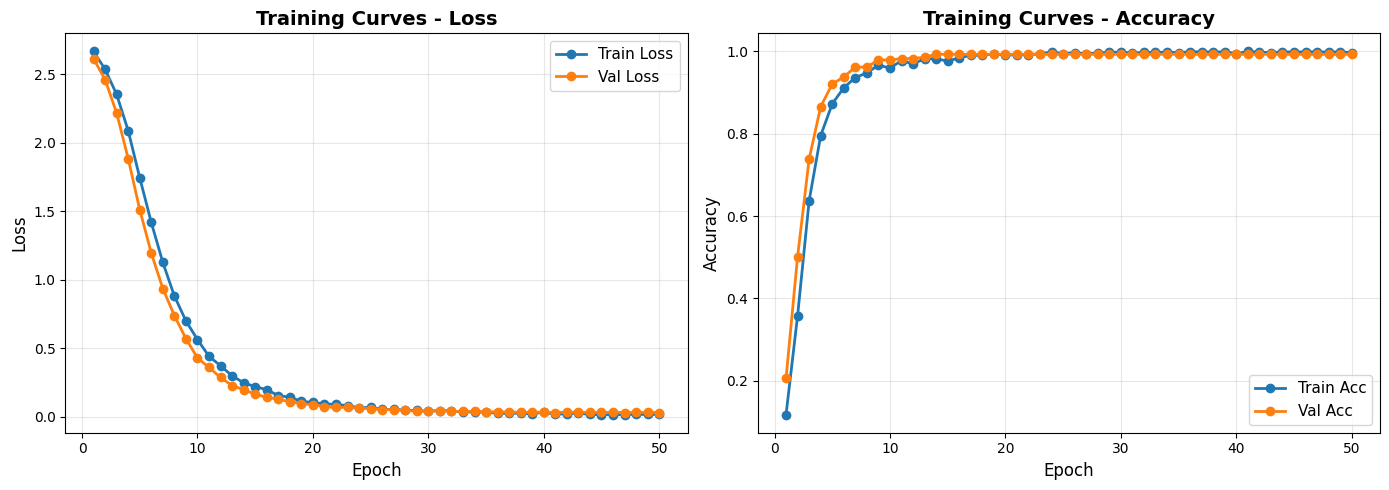

In [14]:
# Plot Training Curves

plot_training_curves(history_partial)

Smooth convergence ,and after about 10-15 epochs validation and train track each other closely, stable training with no overfitting

In [15]:
# Test Acc and Loss

partial_test_loss, partial_test_acc = evaluate(model_partial, test_loader, device)
print(f'Test loss: {partial_test_loss:.4f}')
print(f'Test accuracy: {partial_test_acc:.4f}')

Test loss: 0.0379
Test accuracy: 0.9932


- Accuracy about the same as Frozen Backbone with about ~0.5 in favor of partial. (Make sense as acc at this level is approaching ceiling performance)

- Loss improved from ~0.19 with Frozen Backbone, to ~0.04 with partial.

**Insights**:

- Layer 4 unfreezing allowed more confident predictions (lower loss)

- Fine-tuning high-level features (animal-specific patterns) can be very beneficial to our dataset

# Experiment 3: Full Fine-Tuning

**Strategy**: Train all layers
- Maximum adaptation: All layers adjust to animal dataset
- Slowest training expected
- Risk of overfitting
- Possibly best potential performance: Full model adapts to new domain
- We will use lower LR to avoid catastrophic forgetting

In [16]:
print('Experiment 3: Full Fine-Tuning\n')

model_full = models.resnet50(weights=ResNet50_Weights.DEFAULT)
model_full.fc = nn.Linear(model_full.fc.in_features, n_classes)
model_full = model_full.to(device)

print(f'Trainable parameters: {count_trainable_params(model_full):,}\n')

optimizer_full = torch.optim.Adam(model_full.parameters(), lr=0.00001, weight_decay=WEIGHT_DECAY)
start_time = time.time()
model_full, history_full = train(model_full, train_loader, val_loader, optimizer_full, EPOCHS, PATIENCE, device)
train_time_full = time.time() - start_time

print(f'\nTraining time: {train_time_full/60:.2f} min')

Experiment 3: Full Fine-Tuning

Trainable parameters: 23,538,767

Epoch 1/50 - Train Loss: 2.6533 - Train Acc: 0.1368 - Val Loss: 2.5697 - Val Acc: 0.2990
Epoch 5/50 - Train Loss: 1.6064 - Train Acc: 0.8963 - Val Loss: 1.3306 - Val Acc: 0.9519
Epoch 10/50 - Train Loss: 0.3733 - Train Acc: 0.9868 - Val Loss: 0.2774 - Val Acc: 0.9966
Epoch 15/50 - Train Loss: 0.1149 - Train Acc: 0.9956 - Val Loss: 0.0908 - Val Acc: 0.9931
Epoch 20/50 - Train Loss: 0.0512 - Train Acc: 0.9993 - Val Loss: 0.0519 - Val Acc: 0.9897
Epoch 25/50 - Train Loss: 0.0306 - Train Acc: 0.9993 - Val Loss: 0.0331 - Val Acc: 0.9931
Epoch 30/50 - Train Loss: 0.0237 - Train Acc: 0.9993 - Val Loss: 0.0265 - Val Acc: 0.9966
Epoch 35/50 - Train Loss: 0.0133 - Train Acc: 1.0000 - Val Loss: 0.0204 - Val Acc: 0.9931
Epoch 40/50 - Train Loss: 0.0120 - Train Acc: 0.9993 - Val Loss: 0.0182 - Val Acc: 0.9966
Epoch 45/50 - Train Loss: 0.0090 - Train Acc: 0.9993 - Val Loss: 0.0185 - Val Acc: 0.9966
Epoch 50/50 - Train Loss: 0.0070 - T

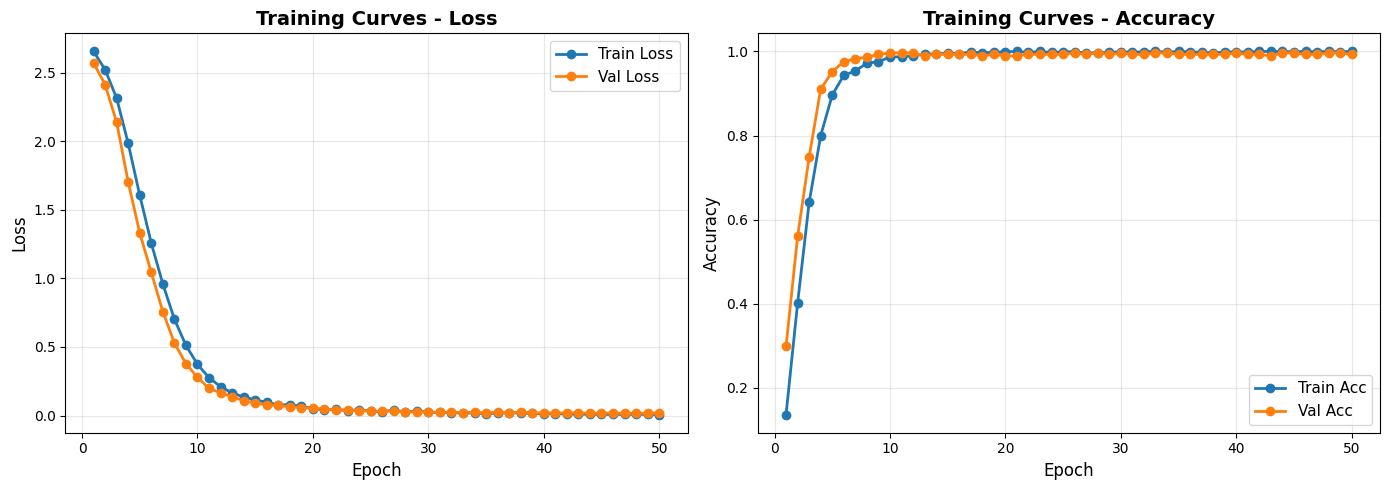

In [17]:
# Plot Training Curves

plot_training_curves(history_full)

Stable training, smooth convergence, train and validation track each other very closely after about 10 epochs, presenting no overfitting

In [18]:
# Test Loss/Acc

full_test_loss, full_test_acc = evaluate(model_full, test_loader, device)
print(f'Test loss: {full_test_loss:.4f}')
print(f'Test accuracy: {full_test_acc:.4f}')

Test loss: 0.0246
Test accuracy: 0.9932


- Same test accuracy as partial, makes sense as this is probably ceiling performance, very high accuracy.

- Test loss improved even further by ~0.013, achieving extremly low test loss, while not overfitting.

**Insights:**

- Full fine tuning had the best results, as adapting the full model to our dataset probably helped even more.

- Although improvements are not massive, the time difference to do full fine tune compared to the others was not bad (at least on colab GPU)

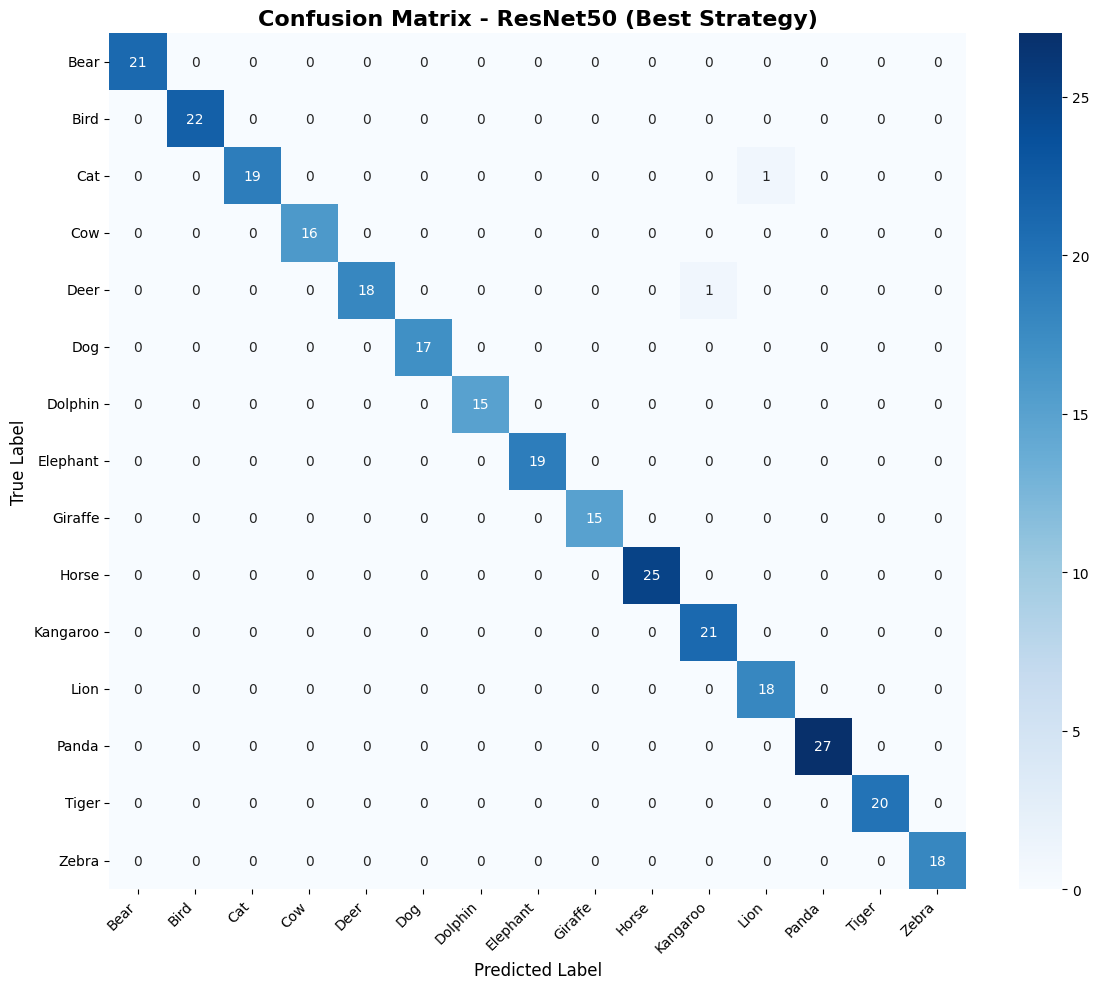

In [23]:
# Plot Confusion Matrix for full-fine tune
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion_matrix(model, test_loader, device, class_names):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            _, pred = torch.max(output.data, 1)
            all_preds.extend(pred.cpu().numpy())
            all_labels.extend(target.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix - ResNet50 (Best Strategy)', fontsize=16, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    return cm

animal_classes = base_dataset.classes
cm_resnet = plot_confusion_matrix(model_full, test_loader, device, animal_classes)

# Comparison - ResNet50 Stradegies

In [21]:
# Compare all three ResNet50 approaches
import pandas as pd

results_resnet = {
    'Strategy': ['Frozen Backbone', 'Partial (layer4+FC)', 'Full Fine-Tuning'],
    'Trainable Params': [
        f'{count_trainable_params(model_frozen):,}',
        f'{count_trainable_params(model_partial):,}',
        f'{count_trainable_params(model_full):,}'
    ],
    'Training Time (min)': [
        f'{train_time_frozen/60:.2f}',
        f'{train_time_partial/60:.2f}',
        f'{train_time_full/60:.2f}'
    ],
    'Val Accuracy': [
        f'{max(history_frozen["val_acc"]):.4f}',
        f'{max(history_partial["val_acc"]):.4f}',
        f'{max(history_full["val_acc"]):.4f}'
    ], 'Val Loss': [
        f'{min(history_frozen["val_loss"]):.4f}',
        f'{min(history_partial["val_loss"]):.4f}',
        f'{min(history_full["val_loss"]):.4f}'
    ],
    'Test Accuracy': [
        f'{forzen_test_acc:.4f}',
        f'{partial_test_acc:.4f}',
        f'{full_test_acc:.4f}'
    ],
    'Test Loss': [
        f'{frozen_test_loss:.4f}',
        f'{partial_test_loss:.4f}',
        f'{full_test_loss:.4f}'
    ]
}

df_resnet = pd.DataFrame(results_resnet)
print('ResNet50 Transfer Learning: Strategy Comparison\n')
df_resnet

ResNet50 Transfer Learning: Strategy Comparison



,Strategy,Trainable Params,Training Time (min),Val Accuracy,Val Loss,Test Accuracy,Test Loss
0,Frozen Backbone,"30,735",2.80,0.9828,0.1968,0.9898,0.1947
1,Partial (layer4+FC),"14,995,471",2.94,0.9931,0.0306,0.9932,0.0379
2,Full Fine-Tuning,"23,538,767",3.67,0.9966,0.0151,0.9932,0.0246


# Comparison: ResNet50 vs Custom CNN

Compare ResNet50 with previous models:
- Custom CNN (from scratch)
- Custom CNN (CIFAR-10 transfer)

In [22]:
results_all = {
    'Model': [
        'Custom CNN (From Scratch)',
        'Custom CNN (CIFAR-10 Transfer)',
        'ResNet50 (Frozen)',
        'ResNet50 (Partial)',
        'ResNet50 (Full)'
    ],
    'Pretraining': [
        'None',
        'CIFAR-10 (32×32)',
        'ImageNet (224×224)',
        'ImageNet (224×224)',
        'ImageNet (224×224)'
    ],
    'Val Accuracy': [
        '95.19%',
        '89.35%',
        f'{max(history_frozen["val_acc"])*100:.2f}%',
        f'{max(history_partial["val_acc"])*100:.2f}%',
        f'{max(history_full["val_acc"])*100:.2f}%'
    ],
    'Test Accuracy': [
        '93.86%',
        '93.52%',
        f'{forzen_test_acc*100:.2f}%',
        f'{partial_test_acc*100:.2f}%',
        f'{full_test_acc*100:.2f}%'
    ],
    'Test Loss': [
        '0.390',
        '0.247',
        f'{frozen_test_loss:.3f}',
        f'{partial_test_loss:.3f}',
        f'{full_test_loss:.3f}'
    ]
}

df_all = pd.DataFrame(results_all)
print('Final Comparison: All Models')
df_all

Final Comparison: All Models


,Model,Pretraining,Val Accuracy,Test Accuracy,Test Loss
0,Custom CNN (From Scratch),None,95.19%,93.86%,0.390
1,Custom CNN (CIFAR-10 Transfer),CIFAR-10 (32×32),89.35%,93.52%,0.247
2,ResNet50 (Frozen),ImageNet (224×224),98.28%,98.98%,0.195
3,ResNet50 (Partial),ImageNet (224×224),99.31%,99.32%,0.038
4,ResNet50 (Full),ImageNet (224×224),99.66%,99.32%,0.025


# Analysis & Insights

### ResNet50 Experiments Insights:

- Frozen approach already gave us amazing performance, reaching almost perfect accuracy, indicating that **pretrained features of ResNet are already very useful, and fit nicely to our dataset.**

- Partial approach (layer4 unfreezing) lowered the loss even further, allowing more confident predictions, it showed that **fine-tuning high-level features (animal-specific patterns) can be very beneficial to our dataset.**

- Full fine-tuning approach reached the best overall score, lowering the loss even further, at the cost of longer training time.

**Conclusion**: The less layers we freeze we gain better performance, at the cost of speed. For this dataset and setup (colab GPU), We would perfer full fine tuning approach.

### Stability:
- **ImageNet pretraining** provides more stable features than CIFAR-10 due to:
  - Same resolution (224×224), instead of (30x30)
  - Larger dataset (1.2M vs 50k)

### Key Takeaways:

1. **ResNet50 vs Custom CNN**:
   - ResNet50 achieve better metrics with less tuning
   - Pretrained features accelerate convergence
   - Trade-off: Model size (~25M vs ~2M params)

2. **ImageNet vs CIFAR-10 Pretraining**:
   - ImageNet better suited due to resolution match and richness of the dataset
   - CIFAR-10 might benefit upsampling adaptation

3. **Freezing Strategy**:
   - Frozen: Fast baseline, good if dataset is similar to ImageNet
   - Partial: Best balance of speed and performance
   - Full: Best performance, Might be good in cases of very different domains, slowest.